# Learning Outcomes

**Learning Objectives:**

Before going through this section be you have a firm understanding of erosion and dilation. After going through this section, you should be able to:
1. Define opening, and it's application
2. Define closing, and it's application

**Detailed outline of the reading material:**

* Opening

* Closing

* Implementation




## Opening





An opening is the compounded morphological operation derived from the fundamental operations erosion and dilation. Opening somewhat behaves like erosion but less destructive. Here, you remove some foreground pixels from the boundary region of the image. An opening is a process in which erosion operation follows the dilation. You can see this clearly in its mathematical definition presented below.

For any set of foreground elements, $ A $ and structuring element $ B $ opening of A by B is

$$
    A \circ B = (A \ominus B) \oplus B
$$
This means the opening is erosion, followed by dilation using the same structuring elements.

As we know that erosion removes some after of the elements from the foreground, and following the dilation, we refill these parts.

Using the opening, we can smooth surfaces, break narrow ridges, and eliminate protrusions. If you take a square structuring element of 5x5 pixels, you can remove all artifacts with less than 5.

<!-- ![opening and erosion](https://drive.google.com/uc?id=1bGte0upGrKtSbudf58AeEb_4cnKYMET7) -->
![opening and erosion](https://i.postimg.cc/7PcVWwN1/image.png)
<center>Figure 1: Showing the differences between erosion and opening</center>

From the above figure, you can see the differences between erosion and opening. Erosion operation has eroded a lot of the character while Opening operation has thicked the character. The reason for it is that the main task of erosion operation is to erode the image object while opening does two actions: one is erosion, and the other is dilation. Here, the dilation process is overtaking the erosion action and making the character thicker.

**Properties:**

* Idempotent

  $$(A\circ B) \circ B = A\circ B$$

* Increasing monotonicity

  If $A\subseteq C$, $A\circ B \subseteq C\circ B$, where A and C are image objects, and B is  structuring element

*  Translation Invariant

  $$ (A +x)\circ B = (A\circ B)+x$$



# Closing

Closing is the dual of the opening process. It is the composite operation derived from fundamental operations erosion and dilation. It is similar to dilation in some manner as it tends to increase the boundary of the foreground regions in an image. It is the reverse process of opening. As the opening is erosion followed by dilation, it is dilation followed by erosion, as shown in the mathematical definition below.



For any set of foreground elements, $A$ and structuring element $B$ closing of A by B is,

$$
    A \bullet B = (A \oplus B) \ominus B
$$
This means closing is dilation, followed by erosion using the same structuring elements.

Unlike opening that removes all the structure where the structuring elements don't fit, closing fills all the background elements where structure elements don't fit. Therefore it can be used as fusions for small breaks, thing gulfs, and small holes.

<!-- ![closing and dilation](https://drive.google.com/uc?id=13Cd9kPU7kF3mTRRfr1qxHzwwwCpwTatv) -->
![closing and dilation](https://i.postimg.cc/JzytdCPX/image.png)
<center>Figure 2: Showing the differences between dilation and closing operations

From the above figure, you can see the differences between the dilation and closing operations. The dilation operations made the character thicker than the closing operation. It is so because the main task of dilation is to add foreground pixels to the image while closing operation performs two tasks: one is dilation and erosion, and the erosion task erodes the character enlarged by the dilation task.

**Properties:**

* Idempotent

  $$(A\bullet B) \bullet B = A\bullet B$$

* Increasing monotonicity

  If $A\subseteq C$, $A\bullet B \subseteq C\bullet B$, where A and C are image objects, and B is  structuring element

*  Translation Invariant

  $$ (A +x)\bullet B = (A\bullet B)+x$$

**Note:**

* Opening and closing both shows the duality property which is as ahown below:

  $$(A\bullet B)^\complement  = (A^\complement \circ \hat{B})$$
$$(A\circ B)^\complement  = (A^\complement \bullet \hat{B})$$
  $\hat{B}$ denotes reflection of B

  This means that you can perform closing(opening) by taking the complement of the image, opening(closing) with the structuring element, and taking the result's complement.

* You can use opening when the image has many small regions. Don't use it where there is a chance that the initial erosion operation might disconnect the region.

* You can use closing when a region becomes disconnected and reconstruction is required.


# Implementation

In [ ]:
!curl -o img.jpg "https://upload.wikimedia.org/wikipedia/commons/thumb/9/9e/Plain_whorl_in_a_right_thumbprint.jpg/640px-Plain_whorl_in_a_right_thumbprint.jpg"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  154k  100  154k    0     0   553k      0 --:--:-- --:--:-- --:--:--  553k


In [ ]:
!curl -o img.png "https://docs.opencv.org/3.4/Morphology_1_Tutorial_Theory_Original_Image.png"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1126  100  1126    0     0   1819      0 --:--:-- --:--:-- --:--:--  1816


In [ ]:
# Implementation
import cv2
import numpy as np
import matplotlib.pyplot as plt


Text(0.5, 1.0, 'After closing the opened')

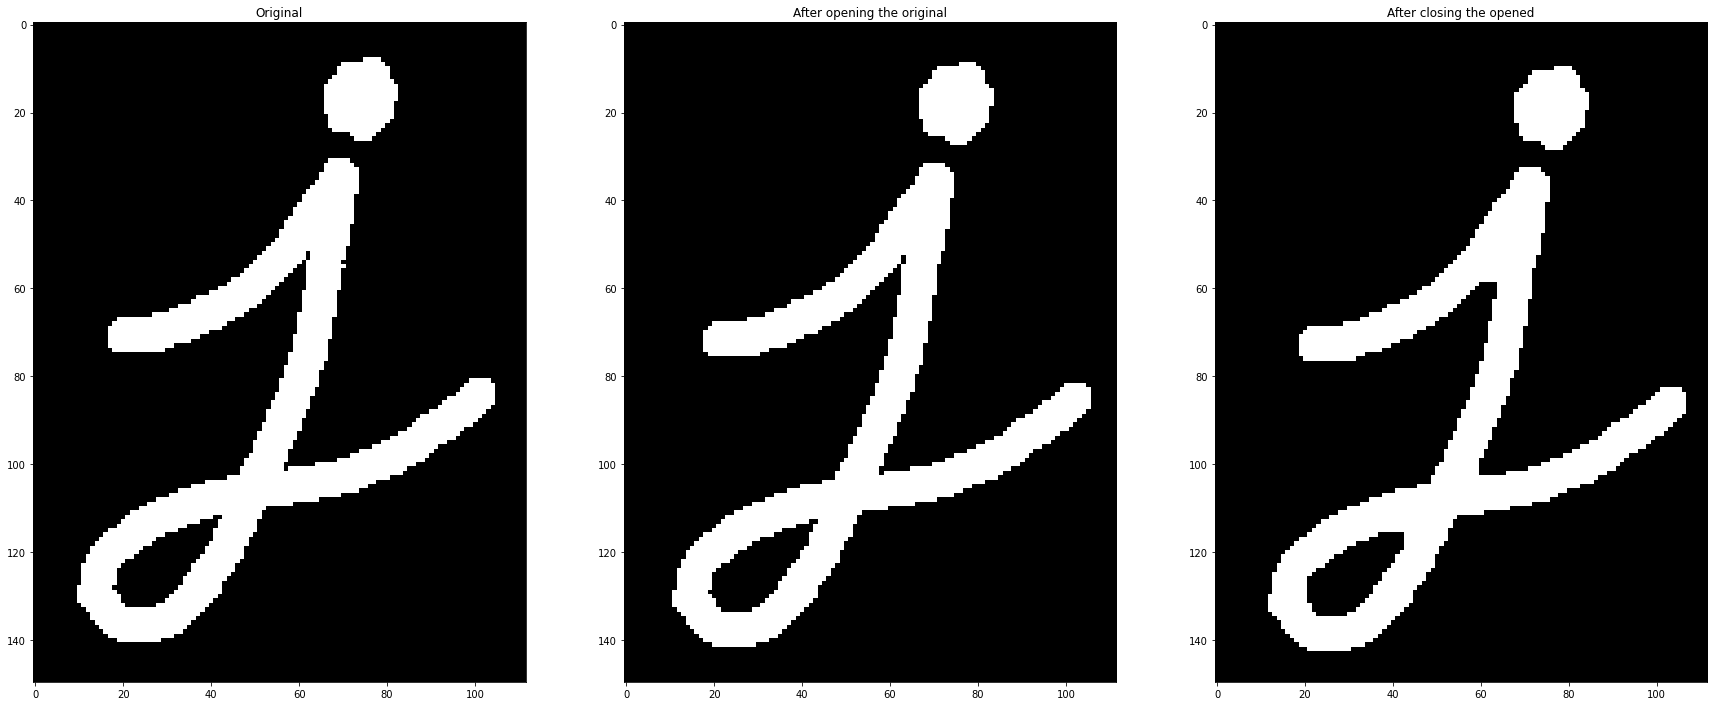

In [ ]:
img = cv2.imread("img.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, img = cv2.threshold(img, 127, 255,cv2.THRESH_BINARY)
kernel = np.ones((4, 4), np.uint8)

# opening
opened = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
# closing after opening
closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)
fig = plt.figure(figsize=(30,20))

ax1 = fig.add_subplot(1, 3, 1)
ax1.imshow(img, cmap="gray")
ax1.set_title("Original")
ax2 = fig.add_subplot(1, 3, 2)
ax2.imshow(opened, cmap="gray")
ax2.set_title("After opening the original")
ax3 = fig.add_subplot(1, 3, 3)
ax3.imshow(closed, cmap="gray")
ax3.set_title("After closing the opened")

In [ ]:
img = cv2.imread("testtext.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, img = cv2.threshold(img, 127, 255,cv2.THRESH_BINARY)
kernel = np.ones((4, 4), np.uint8)


# opening
opened = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
# closing after opening
closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)
fig = plt.figure(figsize=(30,20))

# dilation = cv2.dilate(img,kernel,iterations = 1)
# plt.imshow(img)

# img = cv.imread('j.png',0)
kernel1 = np.ones((3,3),np.uint8)
# erosion1 = cv2.morphologyEx(img,cv2.MORPH_HITMISS, kernel)
erosion1 = cv2.dilate(img, kernel1, iterations=1)
kernel2 = np.ones((3,3),np.uint8)
erosion2 = cv2.erode(erosion1,kernel2,iterations = 1)

ax1 = fig.add_subplot(1, 3, 1)
ax1.axis('off')
ax1.imshow(img, cmap='gray')
ax2 = fig.add_subplot(1, 3, 2)
ax2.axis('off')
ax2.imshow(erosion1, cmap='gray')
ax3 = fig.add_subplot(1, 3, 3)
ax3.axis('off')
ax3.imshow(erosion2, cmap='gray')
# ax1 = fig.add_subplot(1, 3, 1)
# ax1.imshow(img, cmap="gray")
# ax1.set_title("Original")
# ax2 = fig.add_subplot(1, 3, 2)
# ax2.imshow(opened, cmap="gray")
# ax2.set_title("After opening the original")
# ax3 = fig.add_subplot(1, 3, 3)
# ax3.imshow(closed, cmap="gray")
# ax3.set_title("After closing the opened")

As you can see, performing closing after opening the final result has significantly less amount of noise.

# Key Takeaways

1. The opening can be used to smoothen, break narrow ridges and eliminate protrusions
2. Closing can be used to fuse narrow breaks, thin gulfs, and small holes.